# Import

In [1]:
!pip install beautifulsoup4
!pip install requests

In [2]:
import requests
import csv
from bs4 import BeautifulSoup as bs
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Scrape pages

In [3]:
csv_file = open('all_recipes.csv','w', encoding='utf-8')
csv_writer = csv.writer(csv_file)
csv_writer.writerow(['Title', 'Calories', 'Personal Point', 'Summary', 'Keys', 'Image'])

50

In [4]:
def scrape_page(page_url):
  r = requests.get(page_url)
  soup = bs(r.text, 'html.parser')
  food_title_tags = soup.select("h2.entry-title a")
  for a in food_title_tags:
      title, link = a.get_text(), a['href']
      recipe_soup = bs(requests.get(link).text, 'html.parser')

      try:
        personal_point = recipe_soup.select_one("span.wprm-recipe-custom-field-key-ww_personal_points")
        calories = recipe_soup.select_one("span.wprm-recipe-calories")
        image = recipe_soup.select_one("div.wprm-recipe-image img")
        keys = recipe_soup.select_one("ul.cat-icons.post-icons")
        summary = recipe_soup.select_one("div.wprm-recipe-summary.wprm-block-text-normal")

        csv_writer.writerow([title,
                             calories.get_text().replace("Cals:", "").strip(),
                             personal_point.get_text().strip(),
                             summary.get_text().strip(),
                             [a_tag.get_text() for a_tag in keys.select('a')] if keys!=None else None,
                             image.get('data-lazy-src').strip() or image.get('src').strip()])
      except Exception as e:
          continue

In [5]:
scrape_page(f"https://www.skinnytaste.com/recipe-index/")
for i in range(2,51):
  scrape_page(f"https://www.skinnytaste.com/recipe-index/?_paged={i}")

In [6]:
all_recipes = pd.read_csv('all_recipes.csv')
all_recipes.head(10)

,Title,Calories,Personal Point,Summary,Keys,Image
0,Instant Pot Spaghetti with Meat Sauce,530.0,8,This hearty Instant Pot Spaghetti and Meat Sau...,"['GF', 'HP', 'HF', 'KF', 'PC', 'Q']",https://www.skinnytaste.com/wp-content/uploads...
1,Pozole Rojo Recipe (Made in the Instant Pot!),365.0,5,This easy Instant Pot Pozole Rojo recipe is ma...,"['DF', 'FM', 'GF', 'HF', 'KF', 'PC']",https://www.skinnytaste.com/wp-content/uploads...
2,Creamy Chicken Corn Chowder,378.0,2,Pureed corn and mashed potatoes make this chic...,"['GF', 'KF']",https://www.skinnytaste.com/wp-content/uploads...
3,Parmesan Zucchini,108.0,4,Quick and easy Parmesan Zucchini is the perfec...,"['GF', 'KF', 'LC', 'Q', 'V']",https://www.skinnytaste.com/wp-content/uploads...
4,Air Fryer Meatball Subs,494.0,8,"Air Fryer Meatball Subs are an easy, healthy t...","['AF', 'FM', 'GF', 'HP', 'KF']",https://www.skinnytaste.com/wp-content/uploads...
5,Apple Crisp,207.0,6,This easy Apple Crisp recipe is made with bake...,"['GF', 'HF', 'KF', 'V']",https://www.skinnytaste.com/wp-content/uploads...
6,Apple Butter Recipe (Stovetop),34.0,1,"This homemade apple butter is thick, smooth, a...","['DF', 'GF', 'KF', 'V']",https://www.skinnytaste.com/wp-content/uploads...
7,Drunken Noodles (Pad Kee Mao),487.0,3,"Spicy, savory, and slightly sweet, this Drunke...","['DF', 'GF', 'HP']",https://www.skinnytaste.com/wp-content/uploads...
8,Pork Milanese with Kale and Apple Salad,323.0,7,This Pork Milanese with kale and apple salad i...,"['AF', 'GF', 'HP', 'HF']",https://www.skinnytaste.com/wp-content/uploads...
9,Pumpkin Lasagna Skillet,483.0,11,This Pumpkin Lasagna Skillet is the ultimate f...,"['FM', 'HP']",https://www.skinnytaste.com/wp-content/uploads...


# Visualization

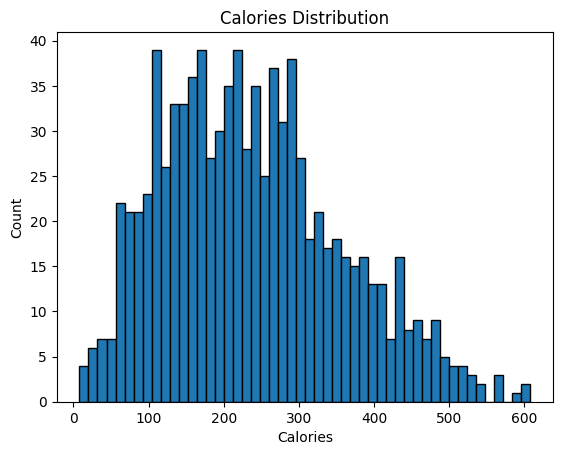

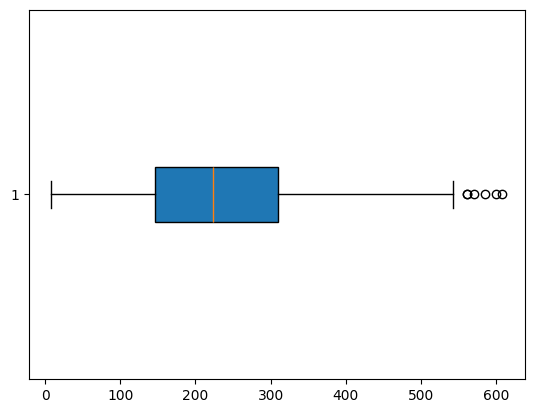

In [7]:
plt.hist(all_recipes['Calories'].dropna(), bins=50, edgecolor='black')
plt.xlabel("Calories")
plt.ylabel("Count")
plt.title("Calories Distribution")
plt.show()


calories = all_recipes['Calories'].dropna()
plt.boxplot(calories, vert=False, patch_artist=True)
plt.show()

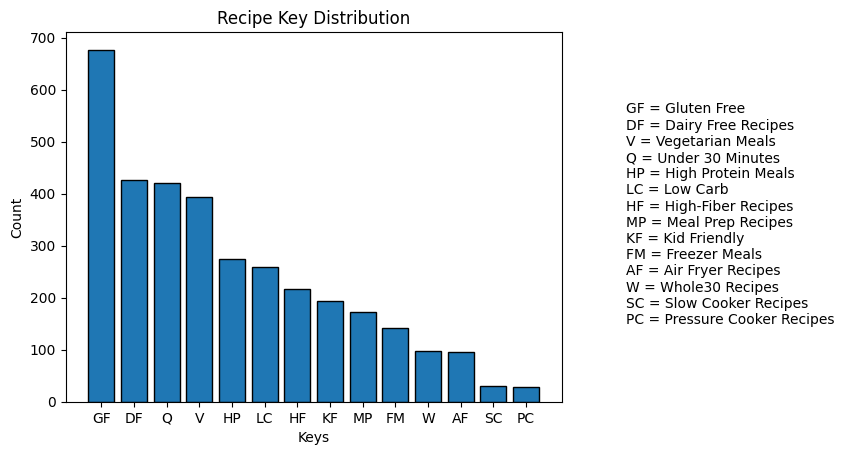

In [8]:
tags_explain = {
    "GF": "Gluten Free",
    "DF": "Dairy Free Recipes",
    "V": "Vegetarian Meals",
    "Q": "Under 30 Minutes",
    "HP": "High Protein Meals",
    "LC": "Low Carb",
    "HF": "High-Fiber Recipes",
    "MP": "Meal Prep Recipes",
    "KF": "Kid Friendly",
    "FM": "Freezer Meals",
    "AF": "Air Fryer Recipes",
    "W": "Whole30 Recipes",
    "SC": "Slow Cooker Recipes",
    "PC": "Pressure Cooker Recipes"
}

all_keys = []
for keys_list in all_recipes['Keys']:
    if isinstance(keys_list, str):
        keys_list = eval(keys_list)
        for key in keys_list:
            all_keys.append(key)

freq = pd.Series(all_keys).value_counts()
plt.bar(freq.index, freq.values, edgecolor="black")

guide_text = "\n".join([f"{k} = {v}" for k,v in tags_explain.items()])
plt.gcf().text(1, 0.5, guide_text, va="center")

plt.xlabel("Keys")
plt.ylabel("Count")
plt.title("Recipe Key Distribution")
plt.show()

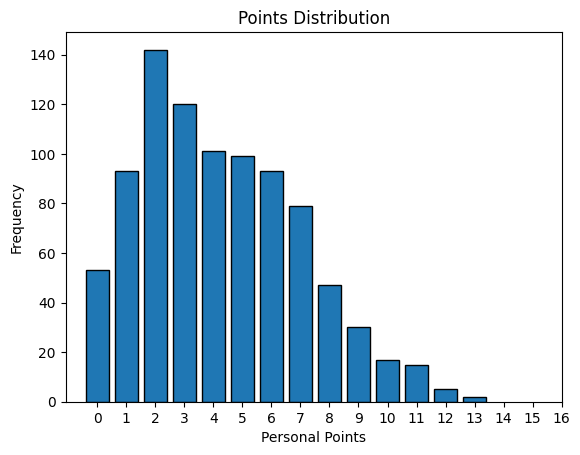

In [9]:
freq = all_recipes['Personal Point'].dropna().value_counts()
plt.bar(freq.index, freq.values, edgecolor='black')
plt.xlabel("Personal Points")
plt.ylabel("Frequency")
plt.title("Points Distribution")
plt.xticks(range(0,17))
plt.show()

# User Interaction

In [10]:

cal_range = input("Enter calorie range (with a space): ").split()
calorie_min, calorie_max = int(cal_range[0]), int(cal_range[1])
point_range = input("Enter personal point range (with a space): ").split()
point_min, point_max = int(point_range[0]), int(point_range[1])

filtered_recipes = all_recipes[
    (all_recipes['Calories'] >= calorie_min) &
    (all_recipes['Calories'] <= calorie_max) &
    (all_recipes['Personal Point'] >= point_min) &
    (all_recipes['Personal Point'] <= point_max)
].sort_values(by='Calories')
top_10_recipes = filtered_recipes.head(10)

print("\nTop 10 Recipes (lowest calorie to highest calorie):")
for idx, row in top_10_recipes.iterrows():
    display(Image(url=row['Image'], width=200, height=200))
    print(f"Title: {row['Title']}")
    print(f"Calories: {row['Calories']}")
    print(f"Personal Point: {row['Personal Point']}")
    print(f"Summary: {row['Summary']}")
    print("*****************************************************************************************************")


Enter calorie range (with a space): 500 600
Enter personal point range (with a space): 4 8

Top 10 Recipes (lowest calorie to highest calorie):


Title: Honey Sriracha Roasted Salmon Rice Bowls (GF, DF)
Calories: 506.0
Personal Point: 8
Summary: Honey and sriracha make a sweet and spicy glaze for bite-sized salmon pieces. Add rice and some veggies, and you have a complete meal in no time!
*****************************************************************************************************


Title: Tofu Poke Bowl
Calories: 520.0
Personal Point: 7
Summary: If you want a tasty plant-based dinner, you'll love these vegan Tofu Poke Bowls that replace tuna poke with tofu.
*****************************************************************************************************


Title: Air Fryer Breaded Chicken Breast
Calories: 525.0
Personal Point: 8
Summary: Ditch the mess of multiple breading stations with this one-bowl Air Fryer Breaded Chicken Breast bites paired with a simple salad!
*****************************************************************************************************


Title: Instant Pot Spaghetti with Meat Sauce
Calories: 530.0
Personal Point: 8
Summary: This hearty Instant Pot Spaghetti and Meat Sauce packs over 30 grams of protein per serving thanks to lean ground turkey and pasta, all cooked together in one pot. Ready in under 30 minutes, it’s the perfect high-protein weeknight dinner with minimal cleanup.
*****************************************************************************************************


Title: 5-Minute Microwave Salmon Rice Bowl with Bok Choy
Calories: 533.0
Personal Point: 5
Summary: If you don’t have time to cook, you’ll love this 5-minute Salmon Rice Bowl with Bok Choy made in the microwave!
*****************************************************************************************************


Title: Air Fryer Chicken Milanese with Mediterranean Salad
Calories: 562.0
Personal Point: 8
Summary: This crispy Air Fryer Breaded Chicken Breast is topped with a Mediterranean Salad of tomatoes, red onion, romaine lettuce, and grated Feta cheese – so good!
*****************************************************************************************************


Title: White Bean Scampi with Linguine
Calories: 571.0
Personal Point: 8
Summary: This white bean scampi served over whole-wheat linguine provides a lighter vegetarian alternative to shrimp scampi.
*****************************************************************************************************


Title: Roasted Sweet Potato Black Bean Bowls
Calories: 585.0
Personal Point: 7
Summary: These Roasted Sweet Potato and Chipotle Black Bean Bowls are a filling vegetarian lunch or dinner, perfect for meal prep.
*****************************************************************************************************
